<a href="https://colab.research.google.com/github/Janinduthenura/Train-journey-prediction/blob/main/Copy_of_train_schedule.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/My Drive/Dataset1.csv')

df.head()

,SN,Train_No,Station_Code,1A,2A,3A,SL,Station_Name,Route_Number,Arrival_time,Departure_Time,Distance
0,1,107,SWV,100,100,100,100,SAWANTWADI R,1,00:00:00,10:25:00,0
1,2,107,THVM,260,228,196,164,THIVIM,1,11:06:00,11:08:00,32
2,3,107,KRMI,345,296,247,198,KARMALI,1,11:28:00,11:30:00,49
3,4,107,MAO,490,412,334,256,MADGOAN JN.,1,12:10:00,00:00:00,78
4,1,108,MAO,100,100,100,100,MADGOAN JN.,1,00:00:00,20:30:00,0


In [ ]:
df.shape

(186074, 12)

In [ ]:
print("=" * 50)
print("NULL VALUE ANALYSIS")
print("=" * 50)

null_counts = df.isnull().sum()
print("\n📊 NULL COUNTS PER COLUMN:")
print(null_counts[null_counts > 0])  # Show only columns with nulls

# Calculate percentage of nulls
null_percentages = (df.isnull().sum() / len(df)) * 100
print("\n📈 NULL PERCENTAGES PER COLUMN:")
print(null_percentages[null_percentages > 0].round(2))

NULL VALUE ANALYSIS

📊 NULL COUNTS PER COLUMN:
Series([], dtype: int64)

📈 NULL PERCENTAGES PER COLUMN:
Series([], dtype: float64)


In [ ]:
print("=" * 60)
print("DUPLICATE RECORDS ANALYSIS")
print("=" * 60)

# Check for exact duplicate rows (all columns identical)
exact_duplicates = df.duplicated().sum()
print(f"\n🔍 Exact duplicate rows (all columns identical): {exact_duplicates}")

# Check for duplicates based on key columns (what should be unique)
key_columns = ['Train_No', 'SN']  # Each train should have unique SN
key_duplicates = df.duplicated(subset=['Train_No', 'SN']).sum()
print(f"\n🔑 Duplicates based on Train_No + SN (should be unique): {key_duplicates}")

DUPLICATE RECORDS ANALYSIS

🔍 Exact duplicate rows (all columns identical): 0

🔑 Duplicates based on Train_No + SN (should be unique): 0


In [ ]:
# Get all unique stations
unique_stations = df['Station_Name'].unique()
unique_stations_sorted = sorted(unique_stations)

print("="*50)
print("LIST OF ALL STATIONS")
print("="*50)
print(f"Total unique stations: {len(unique_stations_sorted)}")
print("\nStation names:")
for i, station in enumerate(unique_stations_sorted, 1):
    print(f"{i:3}. {station}")

Streaming output truncated to the last 5000 lines.
3100. JALESWAR
3101. JALGAON JN.
3102. JALIADEWANI
3103. JALILA ROAD
3104. JALINDRI
3105. JALIYA
3106. JALNA
3107. JALOR
3108. JALPAIGURI
3109. JALPAIGURI R
3110. JALPUR  HALT
3111. JALSU
3112. JALSU NANAK
3113. JAM JODHPUR
3114. JAMA
3115. JAMADOBA PH
3116. JAMAI-OSMANI
3117. JAMALPUR JN.
3118. JAMALPUR SHA
3119. JAMBARA
3120. JAMBHALI  HA
3121. JAMBUR
3122. JAMDHA
3123. JAMES STREET
3124. JAMGA
3125. JAMGURI
3126. JAMIKUNTA
3127. JAMIRA
3128. JAMIRA HALT
3129. JAMIRGHATA
3130. JAMMALAMADUG
3131. JAMMU TAWI
3132. JAMNAGAR
3133. JAMSAR
3134. JAMTARA
3135. JAMUA
3136. JAMUI
3137. JAMUNAMUKH
3138. JAMUNIATANR
3139. JAMWALA
3140. JAMWANTHALI
3141. JANAI ROAD
3142. JANAKINAGAR
3143. JANAKPUR ROA
3144. JANDIALA
3145. JANDRAPETA H
3146. JANGAON
3147. JANGHAI JN.
3148. JANGIGANJ
3149. JANGIPUR ROA
3150. JANIYANA
3151. JANKAMPET JN
3152. JANKIDAIPUR
3153. JANNAGHATTA
3154. JANWAL
3155. JAPLA
3156. JARAIKELA
3157. JARANDESHWAR
3158. JARANGDIH
3

In [ ]:
print("="*80)
print("FINDING STATIONS WITH INCONSISTENT CODES")
print("="*80)

# Group by station name and check unique codes
station_analysis = df.groupby('Station_Name').agg({
    'Station_Code': ['nunique', 'unique', 'count']
}).round(2)

station_analysis.columns = ['code_count', 'codes_used', 'record_count']
station_analysis = station_analysis.reset_index()

# Find stations with multiple codes
inconsistent_stations = station_analysis[station_analysis['code_count'] > 1]

# Find stations with single code (consistent)
consistent_stations = station_analysis[station_analysis['code_count'] == 1]

print(f"\n📊 SUMMARY STATISTICS:")
print("-"*40)
print(f"Total unique stations: {len(station_analysis)}")
print(f"✅ Stations with consistent codes: {len(consistent_stations)}")
print(f"❌ Stations with inconsistent codes: {len(inconsistent_stations)}")
print(f"📝 Total records analyzed: {len(df)}")

if len(inconsistent_stations) > 0:
    print("\n" + "="*80)
    print("❌ STATIONS WITH MULTIPLE CODES")
    print("="*80)

    # Sort by record count to see most important ones first
    inconsistent_stations = inconsistent_stations.sort_values('record_count', ascending=False)

    for idx, row in inconsistent_stations.iterrows():
        print(f"\n📍 {row['Station_Name']}")
        print(f"   Total records: {row['record_count']}")
        print(f"   Number of different codes: {row['code_count']}")
        print(f"   Codes used: {row['codes_used']}")

        # Show frequency of each code for this station
        code_freq = df[df['Station_Name'] == row['Station_Name']]['Station_Code'].value_counts()
        print("   Code frequencies:")
        for code, freq in code_freq.items():
            print(f"      • {code}: {freq} records")

        # Suggest the most frequent code as the correct one
        most_common = code_freq.index[0]
        most_common_count = code_freq.iloc[0]
        print(f"   💡 Suggested correct code: {most_common} (used in {most_common_count} records)")

    # Save inconsistent stations to CSV
    inconsistent_stations.to_csv('/content/drive/My Drive/inconsistent_stations.csv', index=False)
    print(f"\n✅ Detailed report saved to: /content/drive/My Drive/inconsistent_stations.csv")
else:
    print("\n✅ All stations have consistent codes! Great job!")

FINDING STATIONS WITH INCONSISTENT CODES

📊 SUMMARY STATISTICS:
----------------------------------------
Total unique stations: 8099
✅ Stations with consistent codes: 8052
❌ Stations with inconsistent codes: 47
📝 Total records analyzed: 186074

❌ STATIONS WITH MULTIPLE CODES

📍 DADAR
   Total records: 598
   Number of different codes: 2
   Codes used: ['DR' 'DDR']
   Code frequencies:
      • DR: 567 records
      • DDR: 31 records
   💡 Suggested correct code: DR (used in 567 records)

📍 LUCKNOW JN.
   Total records: 385
   Number of different codes: 2
   Codes used: ['LKO' 'LJN']
   Code frequencies:
      • LKO: 295 records
      • LJN: 90 records
   💡 Suggested correct code: LKO (used in 295 records)

📍 PATTABIRAM E
   Total records: 244
   Number of different codes: 2
   Codes used: ['PRES' 'PTMS']
   Code frequencies:
      • PRES: 200 records
      • PTMS: 44 records
   💡 Suggested correct code: PRES (used in 200 records)

📍 TIRUCHIRAPPA
   Total records: 183
   Number of differe

In [ ]:


print("="*80)
print("AUTOMATIC STATION CODE CORRECTION")
print("="*80)

# Create a dictionary of corrections based on most frequent code
corrections = {
    'DADAR': 'DR',
    'LUCKNOW JN.': 'LKO',
    'PATTABIRAM E': 'PRES',
    'TIRUCHIRAPPA': 'TPJ',
    'ANAND VIHAR': 'ANVT',
    'KRISHNA RAJA': 'KJM',
    'SHAHJAHANPUR': 'SPN',
    'SURENDRANAGA': 'SUNR',
    'RAJENDRANAGA': 'RJPB',
    'SITAFALMANDI': 'STPD',
    'ADRA': 'ADRA',
    'TIRUNELVELI': 'TEN',
    'HATHIDAH JN': 'HTZ',
    'GANDHINAGAR': 'GADJ',
    'SIMHACHALAM': 'SCM',
    'PARVATIPURAM': 'PVP',
    'ALIPUR DUAR': 'APDJ',
    'SABARMATI JN': 'SBI',
    'MUMBAI CENTR': 'BCT',
    'BELA': 'BELA',
    'RAGHUNATHPUR': 'RPR',
    'ITWARI JN.': 'ITR',
    'KANCHIPURAM': 'CJ',
    'GARHMUKTESAR': 'GMS',
    'HANUMANGARH': 'HMH',
    'JETALSAR JN': 'JLR',
    'SUNAM': 'SFMU',
    'BAHADURPUR': 'BPD',
    'THANA BHAWAN': 'THBN',
    'BISHANPUR HA': 'BSPH',
    'SRINAGAR': 'SINA',
    'MAULA ALI': 'MLY',
    'KALOL': 'KLL',
    'KHODIYAR': 'KHDB',
    'BELAKOBA': 'BLK',
    'KHANAPUR': 'KNP',
    'SUGAPAHARI H': 'SGPA',
    'KAMALPUR HAL': 'KAMP',
    'AMBLIYASAN J': 'UMN',
    'TURKI': 'TUR',
    'DAULATPUR HA': 'DULP',
    'MADHAVNAGAR': 'MDRR',
    'PIPRADIH': 'PPDI',
    'RAMNATHPUR': 'RTR',
    'JAMUNIATANR': 'JNN',
    'SAHELI': 'SAHL',
    'DURGAPURI': 'DURP'
}

print(f"\n📋 Correction dictionary created for {len(corrections)} stations")
print("-"*40)

# Track changes
total_changes = 0
changes_by_station = {}

# Apply corrections
for station, correct_code in corrections.items():
    # Find records for this station with wrong codes
    mask = (df['Station_Name'] == station) & (df['Station_Code'] != correct_code)
    wrong_records = df[mask]

    if len(wrong_records) > 0:
        # Count changes
        changes_by_station[station] = len(wrong_records)
        total_changes += len(wrong_records)

        # Show what will be changed
        print(f"\n📍 {station}")
        print(f"   Correct code: {correct_code}")
        print(f"   Records to fix: {len(wrong_records)}")

        # Show the wrong codes that will be changed
        wrong_codes = wrong_records['Station_Code'].value_counts()
        for code, count in wrong_codes.items():
            print(f"      • {code}: {count} records → {correct_code}")

        # Apply the correction
        df.loc[mask, 'Station_Code'] = correct_code

print("\n" + "="*80)
print("CORRECTION SUMMARY")
print("="*80)
print(f"Total stations corrected: {len(changes_by_station)}")
print(f"Total records updated: {total_changes}")

if total_changes > 0:
    print("\n📊 Changes by station:")
    for station, count in changes_by_station.items():
        print(f"   • {station}: {count} records updated")

# Verify corrections were applied
print("\n" + "="*80)
print("VERIFICATION")
print("="*80)

verification_failed = []
for station, correct_code in corrections.items():
    # Check if any records still have wrong codes
    wrong_still = df[(df['Station_Name'] == station) & (df['Station_Code'] != correct_code)]
    if len(wrong_still) > 0:
        verification_failed.append(station)
        print(f"❌ {station}: Still has {len(wrong_still)} wrong records!")

if len(verification_failed) == 0:
    print("✅ All corrections applied successfully!")

# Save the corrected dataframe
output_path = '/content/drive/My Drive/corrected_stations.csv'
df.to_csv(output_path, index=False)
print(f"\n✅ Corrected data saved to: {output_path}")

# Also save a log of changes
changes_log = pd.DataFrame([
    {'station': station, 'records_corrected': count}
    for station, count in changes_by_station.items()
])
changes_log.to_csv('/content/drive/My Drive/correction_log.csv', index=False)
print(f"✅ Correction log saved to: /content/drive/My Drive/correction_log.csv")

AUTOMATIC STATION CODE CORRECTION

📋 Correction dictionary created for 47 stations
----------------------------------------

📍 DADAR
   Correct code: DR
   Records to fix: 31
      • DDR: 31 records → DR

📍 LUCKNOW JN.
   Correct code: LKO
   Records to fix: 90
      • LJN: 90 records → LKO

📍 PATTABIRAM E
   Correct code: PRES
   Records to fix: 44
      • PTMS: 44 records → PRES

📍 TIRUCHIRAPPA
   Correct code: TPJ
   Records to fix: 36
      • TP: 16 records → TPJ
      • TPTN: 10 records → TPJ
      • TPE: 10 records → TPJ

📍 ANAND VIHAR
   Correct code: ANVT
   Records to fix: 47
      • ANVR: 47 records → ANVT

📍 KRISHNA RAJA
   Correct code: KJM
   Records to fix: 18
      • KRNR: 18 records → KJM

📍 SHAHJAHANPUR
   Correct code: SPN
   Records to fix: 20
      • SZP: 10 records → SPN
      • SXK: 10 records → SPN

📍 SURENDRANAGA
   Correct code: SUNR
   Records to fix: 20
      • SRGT: 20 records → SUNR

📍 RAJENDRANAGA
   Correct code: RJPB
   Records to fix: 22
      • RJQ: 22

In [ ]:
print("="*80)
print("FINDING STATIONS WITH INCONSISTENT CODES")
print("="*80)

# Group by station name and check unique codes
station_analysis = df.groupby('Station_Name').agg({
    'Station_Code': ['nunique', 'unique', 'count']
}).round(2)

station_analysis.columns = ['code_count', 'codes_used', 'record_count']
station_analysis = station_analysis.reset_index()

# Find stations with multiple codes
inconsistent_stations = station_analysis[station_analysis['code_count'] > 1]

# Find stations with single code (consistent)
consistent_stations = station_analysis[station_analysis['code_count'] == 1]

print(f"\n📊 SUMMARY STATISTICS:")
print("-"*40)
print(f"Total unique stations: {len(station_analysis)}")
print(f"✅ Stations with consistent codes: {len(consistent_stations)}")
print(f"❌ Stations with inconsistent codes: {len(inconsistent_stations)}")
print(f"📝 Total records analyzed: {len(df)}")

if len(inconsistent_stations) > 0:
    print("\n" + "="*80)
    print("❌ STATIONS WITH MULTIPLE CODES")
    print("="*80)

    # Sort by record count to see most important ones first
    inconsistent_stations = inconsistent_stations.sort_values('record_count', ascending=False)

    for idx, row in inconsistent_stations.iterrows():
        print(f"\n📍 {row['Station_Name']}")
        print(f"   Total records: {row['record_count']}")
        print(f"   Number of different codes: {row['code_count']}")
        print(f"   Codes used: {row['codes_used']}")

        # Show frequency of each code for this station
        code_freq = df[df['Station_Name'] == row['Station_Name']]['Station_Code'].value_counts()
        print("   Code frequencies:")
        for code, freq in code_freq.items():
            print(f"      • {code}: {freq} records")

        # Suggest the most frequent code as the correct one
        most_common = code_freq.index[0]
        most_common_count = code_freq.iloc[0]
        print(f"   💡 Suggested correct code: {most_common} (used in {most_common_count} records)")

    # Save inconsistent stations to CSV
    inconsistent_stations.to_csv('/content/drive/My Drive/inconsistent_stations.csv', index=False)
    print(f"\n✅ Detailed report saved to: /content/drive/My Drive/inconsistent_stations.csv")
else:
    print("\n✅ All stations have consistent codes! Great job!")

FINDING STATIONS WITH INCONSISTENT CODES

📊 SUMMARY STATISTICS:
----------------------------------------
Total unique stations: 8099
✅ Stations with consistent codes: 8099
❌ Stations with inconsistent codes: 0
📝 Total records analyzed: 186074

✅ All stations have consistent codes! Great job!


In [ ]:
print(df)

        SN  Train_No Station_Code    1A    2A    3A    SL     Station_Name  \
0        1       107          SWV   100   100   100   100     SAWANTWADI R   
1        2       107         THVM   260   228   196   164           THIVIM   
2        3       107         KRMI   345   296   247   198          KARMALI   
3        4       107          MAO   490   412   334   256      MADGOAN JN.   
4        1       108          MAO   100   100   100   100      MADGOAN JN.   
...     ..       ...          ...   ...   ...   ...   ...              ...   
186069   1     22439         NDLS   100   100   100   100        NEW DELHI   
186070   2     22439          UMB  1095   896   697  1095   AMBALA CANT JN   
186071   3     22439          LDH  1660  1348  1036  1660      LUDHIANA JN   
186072   4     22439          JAT  2985  2408  1831  2985       JAMMU TAWI   
186073   5     22439         SVDK  3375  2720  2065  3375  SHMATA VD KATRA   

        Route_Number Arrival_time Departure_Time  Distance  
0 

In [ ]:
unique_trains = df['Train_No'].nunique()
total_records = len(df)

print(f"Total records (rows): {total_records}")
print(f"Number of unique trains: {unique_trains}")

Total records (rows): 186074
Number of unique trains: 11113


In [ ]:
# Assuming your dataframe is named 'df'
# If you've made changes to it, this will save the current state

# Save to Google Drive
output_path = '/content/drive/My Drive/my_dataset.csv'
df.to_csv(output_path, index=False)

print(f"✅ Dataset saved successfully to: {output_path}")
print(f"📊 Shape of saved dataset: {df.shape}")

✅ Dataset saved successfully to: /content/drive/My Drive/my_dataset.csv
📊 Shape of saved dataset: (186074, 12)


In [ ]:
df = df.drop(columns=["Station_Name"])

In [ ]:
print(df[30:47])

    SN  Train_No Station_Code     1A     2A    3A    SL  Route_Number  \
30   1       290          DSJ    100    100   100   100             1   
31   2       290         GADJ   1630   1324  1018   712             1   
32   3       290           JP   1655   1344  1033   722             1   
33   4       290          DPA   1690   1372  1054   736             1   
34   5       290          SWM   2310   1868  1426   984             1   
35   6       290          COR   3635   2928  2221  1514             1   
36   7       290          UDZ   4205   3384  2563  1742             1   
37   8       290          JSM   8400   6740  5080  3420             1   
38   9       290          MDB   9855   7904  5953  4002             1   
39  10       290           FL  11165   8952  6739  4526             1   
40  11       290          BTE  12375   9920  7465  5010             1   
41  12       290          IDH  12635  10128  7621  5114             1   
42  13       290          AGC  12640  10132  7624  

In [ ]:
# Check if we can use this column as the Station order
check = df.sort_values(['Train_No','Route_Number','SN']) \
          .groupby(['Train_No','Route_Number'])['SN'] \
          .apply(lambda x: (x.diff().dropna() == 1).all())

print(check.value_counts())

SN
True     11108
False        5
Name: count, dtype: int64


In [ ]:
# Sort properly
df = df.sort_values(['Train_No','Route_Number','Distance'])

# Create correct station order
df['Station_Order'] = df.groupby(['Train_No','Route_Number']).cumcount() + 1

In [ ]:
print(df[30:47])

    SN  Train_No Station_Code     1A     2A    3A    SL  Route_Number  \
30   1       290          DSJ    100    100   100   100             1   
31   2       290         GADJ   1630   1324  1018   712             1   
32   3       290           JP   1655   1344  1033   722             1   
33   4       290          DPA   1690   1372  1054   736             1   
34   5       290          SWM   2310   1868  1426   984             1   
35   6       290          COR   3635   2928  2221  1514             1   
36   7       290          UDZ   4205   3384  2563  1742             1   
37   8       290          JSM   8400   6740  5080  3420             1   
38   9       290          MDB   9855   7904  5953  4002             1   
39  10       290           FL  11165   8952  6739  4526             1   
40  11       290          BTE  12375   9920  7465  5010             1   
41  12       290          IDH  12635  10128  7621  5114             1   
42  13       290          AGC  12640  10132  7624  

In [ ]:
# Add a new column called "Journey_Duration"

df["Arrival_time"] = pd.to_datetime(df["Arrival_time"], errors="coerce")
df["Departure_Time"] = pd.to_datetime(df["Departure_Time"], errors="coerce")

# Calculate stop duration at each station
df['Stop_Duration'] = (df['Departure_Time'] - df['Arrival_time']).dt.total_seconds() / 60
df['Stop_Duration'] = df['Stop_Duration'].clip(lower=0)  # Handle negative values
journey = df.groupby("Train_No").agg(
    start_time=("Departure_Time","min"),
    end_time=("Arrival_time","max"),
    total_distance=("Distance","max"),
    route=("Route_Number","first")
)

journey["Journey_Duration"] = (
    journey["end_time"] - journey["start_time"]
).dt.total_seconds()/3600

journey = journey.dropna()

print(journey[30:47])

                  start_time            end_time  total_distance  route  \
Train_No                                                                  
2025     2026-03-11 05:00:00 2026-03-11 13:20:00             579      1   
2026     2026-03-11 14:30:00 2026-03-11 23:00:00             569      1   
2191     2026-03-11 00:28:00 2026-03-11 23:14:00            1123      1   
2192     2026-03-11 00:15:00 2026-03-11 22:15:00            1123      1   
2195     2026-03-11 13:20:00 2026-03-11 23:00:00             551      1   
2196     2026-03-11 00:32:00 2026-03-11 23:45:00             549      1   
2515     2026-03-11 00:05:00 2026-03-11 23:55:00            3939      1   
2651     2026-03-11 07:45:00 2026-03-11 09:10:00              62      1   
2652     2026-03-11 16:45:00 2026-03-11 18:10:00              62      1   
2731     2026-03-11 00:10:00 2026-03-11 23:20:00            1854      1   
2732     2026-03-11 00:50:00 2026-03-11 23:40:00            1853      1   
2821     2026-03-11 01:30

/tmp/ipykernel_191/4239939234.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Arrival_time"] = pd.to_datetime(df["Arrival_time"], errors="coerce")
/tmp/ipykernel_191/4239939234.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Departure_Time"] = pd.to_datetime(df["Departure_Time"], errors="coerce")


In [ ]:
# No 1
journey["start_hour"] = journey["start_time"].dt.hour
journey["is_night"] = journey["start_hour"].apply(lambda x:1 if x<6 or x>20 else 0)

In [ ]:
# No 2
station_counts = df.groupby("Train_No")["Station_Order"].max()
journey["num_stations"] = station_counts

In [ ]:
# No 3
journey["avg_speed"] = journey["total_distance"]/journey["Journey_Duration"]

In [ ]:
print(len(journey[journey["avg_speed"] < 45]))

8675


In [ ]:
journey= journey[journey['avg_speed']>45]

In [ ]:
# No 4
# route_traffic = df.groupby("Route_Number")["Train_No"].nunique()
# journey["route_traffic"] = journey["route"].map(route_traffic)

In [ ]:
print(journey[30:47])
print(len(journey))

                  start_time            end_time  total_distance  route  \
Train_No                                                                  
2732     2026-03-11 00:50:00 2026-03-11 23:40:00            1853      1   
2821     2026-03-11 01:30:00 2026-03-11 19:30:00            2066      1   
2822     2026-03-11 00:28:00 2026-03-11 23:35:00            2073      1   
2833     2026-03-11 00:29:00 2026-03-11 23:55:00            2332      1   
2834     2026-03-11 00:55:00 2026-03-11 23:28:00            2351      1   
2841     2026-03-11 02:35:00 2026-03-11 19:50:00            1656      1   
2842     2026-03-11 01:45:00 2026-03-11 23:30:00            1656      1   
2845     2026-03-11 00:35:00 2026-03-11 23:05:00            1770      1   
2846     2026-03-11 00:20:00 2026-03-11 22:57:00            1791      1   
3501     2026-03-11 02:32:00 2026-03-11 22:25:00            1193      1   
3502     2026-03-11 03:00:00 2026-03-11 19:50:00            1193      1   
4419     2026-03-11 00:15

In [ ]:
journey = journey.reset_index()

In [ ]:
print(journey[30:47])

    Train_No          start_time            end_time  total_distance  route  \
30      2732 2026-03-11 00:50:00 2026-03-11 23:40:00            1853      1   
31      2821 2026-03-11 01:30:00 2026-03-11 19:30:00            2066      1   
32      2822 2026-03-11 00:28:00 2026-03-11 23:35:00            2073      1   
33      2833 2026-03-11 00:29:00 2026-03-11 23:55:00            2332      1   
34      2834 2026-03-11 00:55:00 2026-03-11 23:28:00            2351      1   
35      2841 2026-03-11 02:35:00 2026-03-11 19:50:00            1656      1   
36      2842 2026-03-11 01:45:00 2026-03-11 23:30:00            1656      1   
37      2845 2026-03-11 00:35:00 2026-03-11 23:05:00            1770      1   
38      2846 2026-03-11 00:20:00 2026-03-11 22:57:00            1791      1   
39      3501 2026-03-11 02:32:00 2026-03-11 22:25:00            1193      1   
40      3502 2026-03-11 03:00:00 2026-03-11 19:50:00            1193      1   
41      4419 2026-03-11 00:15:00 2026-03-11 21:15:00

In [ ]:
journey = pd.get_dummies(journey, columns=["route"], drop_first=True)

In [ ]:
print(journey[30:47])

    Train_No          start_time            end_time  total_distance  \
30      2732 2026-03-11 00:50:00 2026-03-11 23:40:00            1853   
31      2821 2026-03-11 01:30:00 2026-03-11 19:30:00            2066   
32      2822 2026-03-11 00:28:00 2026-03-11 23:35:00            2073   
33      2833 2026-03-11 00:29:00 2026-03-11 23:55:00            2332   
34      2834 2026-03-11 00:55:00 2026-03-11 23:28:00            2351   
35      2841 2026-03-11 02:35:00 2026-03-11 19:50:00            1656   
36      2842 2026-03-11 01:45:00 2026-03-11 23:30:00            1656   
37      2845 2026-03-11 00:35:00 2026-03-11 23:05:00            1770   
38      2846 2026-03-11 00:20:00 2026-03-11 22:57:00            1791   
39      3501 2026-03-11 02:32:00 2026-03-11 22:25:00            1193   
40      3502 2026-03-11 03:00:00 2026-03-11 19:50:00            1193   
41      4419 2026-03-11 00:15:00 2026-03-11 21:15:00            1916   
42      4420 2026-03-11 03:07:00 2026-03-11 23:20:00            

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
journey["Train_No"] = le.fit_transform(journey["Train_No"])

In [ ]:
print(journey[30:47])

    Train_No          start_time            end_time  total_distance  \
30        30 2026-03-11 00:50:00 2026-03-11 23:40:00            1853   
31        31 2026-03-11 01:30:00 2026-03-11 19:30:00            2066   
32        32 2026-03-11 00:28:00 2026-03-11 23:35:00            2073   
33        33 2026-03-11 00:29:00 2026-03-11 23:55:00            2332   
34        34 2026-03-11 00:55:00 2026-03-11 23:28:00            2351   
35        35 2026-03-11 02:35:00 2026-03-11 19:50:00            1656   
36        36 2026-03-11 01:45:00 2026-03-11 23:30:00            1656   
37        37 2026-03-11 00:35:00 2026-03-11 23:05:00            1770   
38        38 2026-03-11 00:20:00 2026-03-11 22:57:00            1791   
39        39 2026-03-11 02:32:00 2026-03-11 22:25:00            1193   
40        40 2026-03-11 03:00:00 2026-03-11 19:50:00            1193   
41        41 2026-03-11 00:15:00 2026-03-11 21:15:00            1916   
42        42 2026-03-11 03:07:00 2026-03-11 23:20:00            

In [ ]:
features = [
    "total_distance",
    "num_stations",
    "start_hour",
    "is_night","avg_speed","num_stations"
]

X = journey[features]
y = journey["Journey_Duration"]

In [ ]:
print(journey[30:47])

    Train_No          start_time            end_time  total_distance  \
30        30 2026-03-11 00:50:00 2026-03-11 23:40:00            1853   
31        31 2026-03-11 01:30:00 2026-03-11 19:30:00            2066   
32        32 2026-03-11 00:28:00 2026-03-11 23:35:00            2073   
33        33 2026-03-11 00:29:00 2026-03-11 23:55:00            2332   
34        34 2026-03-11 00:55:00 2026-03-11 23:28:00            2351   
35        35 2026-03-11 02:35:00 2026-03-11 19:50:00            1656   
36        36 2026-03-11 01:45:00 2026-03-11 23:30:00            1656   
37        37 2026-03-11 00:35:00 2026-03-11 23:05:00            1770   
38        38 2026-03-11 00:20:00 2026-03-11 22:57:00            1791   
39        39 2026-03-11 02:32:00 2026-03-11 22:25:00            1193   
40        40 2026-03-11 03:00:00 2026-03-11 19:50:00            1193   
41        41 2026-03-11 00:15:00 2026-03-11 21:15:00            1916   
42        42 2026-03-11 03:07:00 2026-03-11 23:20:00            

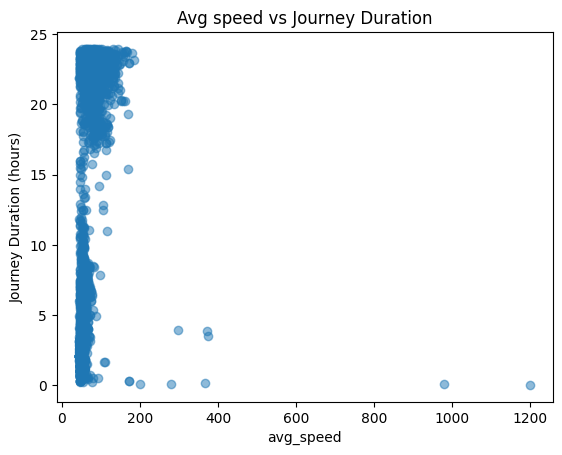

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(journey["avg_speed"], journey["Journey_Duration"], alpha=0.5)
plt.xlabel("avg_speed")
plt.ylabel("Journey Duration (hours)")
plt.title("Avg speed vs Journey Duration")
plt.show()

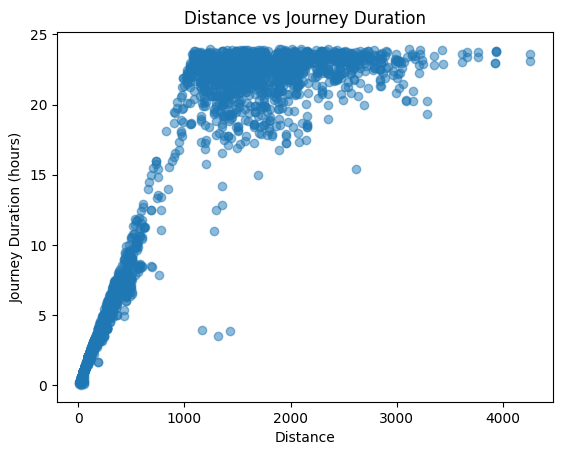

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(journey["total_distance"], journey["Journey_Duration"], alpha=0.5)
plt.xlabel("Distance")
plt.ylabel("Journey Duration (hours)")
plt.title("Distance vs Journey Duration")
plt.show()

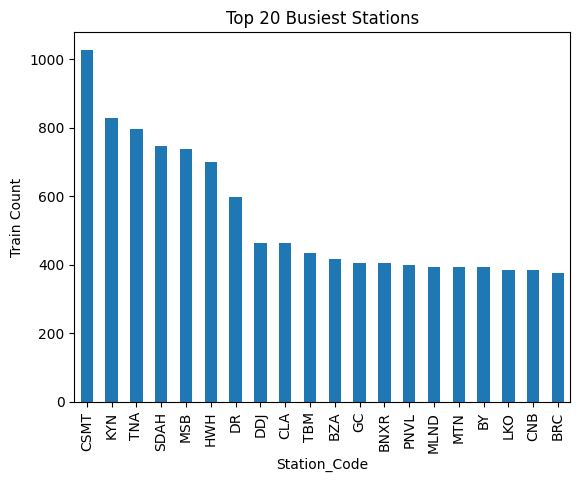

In [ ]:
traffic = df.groupby("Station_Code")["Train_No"].count().sort_values(ascending=False).head(20)

traffic.plot(kind="bar")
plt.title("Top 20 Busiest Stations")
plt.ylabel("Train Count")
plt.show()

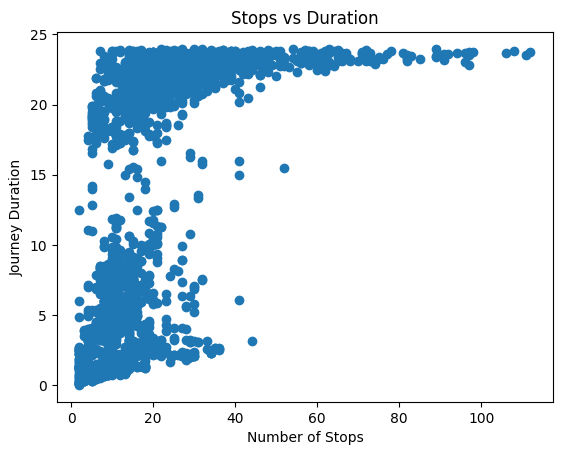

In [ ]:
plt.scatter(journey["num_stations"], journey["Journey_Duration"])
plt.xlabel("Number of Stops")
plt.ylabel("Journey Duration")
plt.title("Stops vs Duration")
plt.show()

In [ ]:
columns_to_check = ['Journey_Duration', 'avg_speed', 'total_distance',]

df_clean = journey.copy()
for col in columns_to_check:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_clean = df_clean[(df_clean[col] >= lower_bound) &
                        (df_clean[col] <= upper_bound)]

journey_no_outliers = df_clean

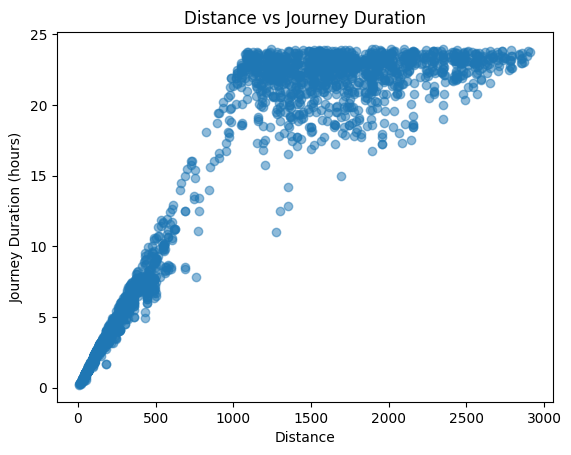

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df_clean["total_distance"], df_clean["Journey_Duration"], alpha=0.5)
plt.xlabel("Distance")
plt.ylabel("Journey Duration (hours)")
plt.title("Distance vs Journey Duration")
plt.show()

In [ ]:
X = df_clean[features]
y = df_clean["Journey_Duration"]

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

# Calculate metrics
r2 = r2_score(y_test, pred)
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))  # Method 1: using np.sqrt()

print("R2 Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

R2 Score: 0.9758781025778571
MAE: 1.1452641100875336
RMSE: 1.4408380274715091
